In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

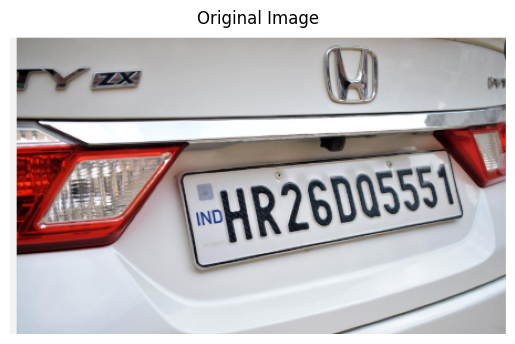

In [2]:
img = cv2.imread("C:/Users/HP/Downloads/number_plate.png")
orig = img.copy()

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

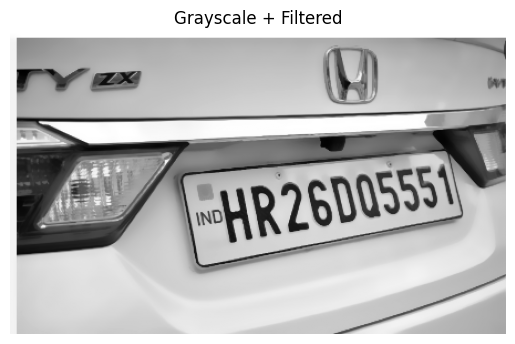

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.bilateralFilter(gray, 11, 17, 17)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale + Filtered")
plt.axis("off")
plt.show()

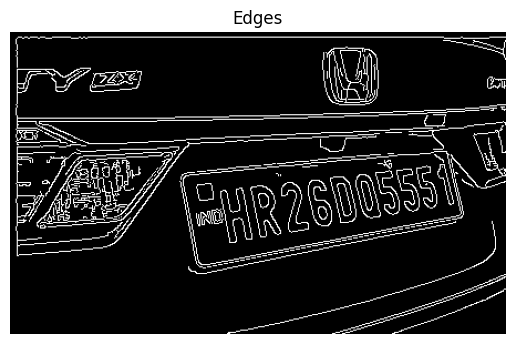

In [4]:
edges = cv2.Canny(gray, 30, 200)

plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.axis("off")
plt.show()

In [5]:
contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

plate = None

for cnt in contours:
    approx = cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), True)

    # relaxed condition (IMPORTANT FIX)
    if 4 <= len(approx) <= 6:
        plate = approx
        break

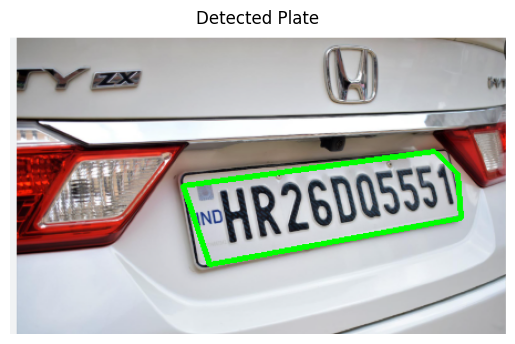

In [6]:
img_contour = img.copy()

if plate is not None:
    cv2.drawContours(img_contour, [plate], -1, (0, 255, 0), 3)
else:
    print("Plate not detected")

plt.imshow(cv2.cvtColor(img_contour, cv2.COLOR_BGR2RGB))
plt.title("Detected Plate")
plt.axis("off")
plt.show()

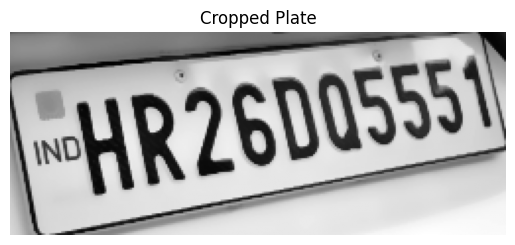

In [7]:
if plate is not None:
    mask = np.zeros(gray.shape, np.uint8)
    cv2.drawContours(mask, [plate], 0, 255, -1)

    (x, y) = np.where(mask == 255)
    (x1, y1) = (np.min(x), np.min(y))
    (x2, y2) = (np.max(x), np.max(y))

    cropped = gray[x1:x2+1, y1:y2+1]

    plt.imshow(cropped, cmap='gray')
    plt.title("Cropped Plate")
    plt.axis("off")
    plt.show()
else:
    print("No plate to crop")

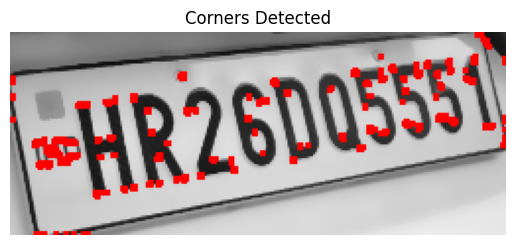

In [8]:
if plate is not None:
    gray_plate = np.float32(cropped)

    dst = cv2.cornerHarris(gray_plate, 2, 3, 0.04)
    dst = cv2.dilate(dst, None)

    cropped_color = cv2.cvtColor(cropped, cv2.COLOR_GRAY2BGR)
    cropped_color[dst > 0.01 * dst.max()] = [0, 0, 255]

    plt.imshow(cv2.cvtColor(cropped_color, cv2.COLOR_BGR2RGB))
    plt.title("Corners Detected")
    plt.axis("off")
    plt.show()